# Compare the Sr88 MQDT models

rydstate provides two sets of MQDT models for $^{88}\mathrm{Sr}$:

- the default models with the tag `robicheaux2019` (`get_mqdt("Sr88", "robicheaux2019")` or simply `get_mqdt("Sr88")`)
  are the eigenchannel models of
  [F. Robicheaux, J. Phys. B 52, 244001 (2019)](https://doi.org/10.1088/1361-6455/ab4c22).
  They only contain the $5snl$ channels and are valid for high effective principal quantum numbers.
- the models with the tag `vaillant2024` (`get_mqdt("Sr88", "vaillant2024")`) are the K-matrix models of
  [C. L. Vaillant, M. P. A. Jones and R. M. Potvliege, J. Phys. B 47, 155001 (2014)](https://doi.org/10.1088/0953-4075/47/15/155001)
  with the corrected parameters of their [Addendum, J. Phys. B 57, 199401 (2024)](https://doi.org/10.1088/1361-6455/ad76f0).
  They include the doubly excited $4dnl$ and $5pnp$ perturber channels explicitly and are therefore valid down to the
  lowest $5snl$ states. The only series they do not cover are the $5snf$ $^3F_J$ series, which are described
  by single channel models with the Rydberg-Ritz quantum defects of
  [E. J. Robertson et al., Comput. Phys. Commun. 261, 107814 (2021)](https://doi.org/10.1016/j.cpc.2020.107814) instead.

As a baseline we also include the default SQDT model (`get_sqdt("Sr88")`), which describes each series by a single
channel with Rydberg-Ritz quantum defects (pure singlet or triplet states without any channel mixing).

This notebook compares the states of the three model sets for several series:
their quantum defects (together with the NIST energy levels shipped with rydstate),
the energy differences of the states with respect to the Vaillant models,
the singlet-triplet mixing of the $5snd$ $J=2$ states and the perturber states, which only the Vaillant models contain.


In [1]:
from __future__ import annotations

# Uncomment the next line if you have ipympl installed and want interactive plots
# %matplotlib widget
import logging
from typing import TYPE_CHECKING

import matplotlib.pyplot as plt
import numpy as np

from rydstate import BasisMQDT
from rydstate.angular.angular_ket import AngularKetLS
from rydstate.species import get_mqdt, get_sqdt
from rydstate.species.utils import calc_energy_from_nu, calc_nu_from_energy
from rydstate.units import au_to_user

if TYPE_CHECKING:
    from rydstate.rydberg_state import RydbergKet

logging.getLogger("rydstate").setLevel(logging.ERROR)  # the radial wavefunctions of the closed perturber channels warn

## Build the bases

We compute all MQDT states with $l_r \le 3$ for $2.5 \le \nu \le 40$ with both model sets.
The Robicheaux models start at $\nu \approx 5$ to $25$ depending on the series, the Vaillant models at $\nu \approx 3$ to $10$.

In [2]:
nu_range = (2.5, 40)
bases = {
    "Robicheaux 2019": BasisMQDT("Sr88", nu=nu_range, l_r=(0, 3), mqdt="robicheaux2019"),
    "Vaillant 2024": BasisMQDT("Sr88", nu=nu_range, l_r=(0, 3), mqdt="vaillant2024"),
}
styles = {  # larger Robicheaux squares, so that they stay visible around the Vaillant circles
    "Robicheaux 2019": {"color": "C1", "marker": "s", "ms": 7.5, "mew": 1.3},
    "Vaillant 2024": {"color": "C0", "marker": "o", "ms": 5},
}

# Both model sets use the 5s ionization threshold of Couturier et al. 2019, 1_377_012_721 MHz = 45932.20024 1/cm.
# The Vaillant models use it rounded to 45932.2002 1/cm, as in the original fits, i.e. the thresholds differ by 1 MHz.
# This is negligible here, so the effective principal quantum numbers nu (and quantum defects) are directly comparable.
thresholds = {
    key: basis.mqdt.get_ionization_threshold(basis.mqdt.get_core_kets()[0], "MHz") for key, basis in bases.items()
}
for key, value in thresholds.items():
    print(f"{key}: 5s ionization threshold {value:.0f} MHz")
threshold_difference_mhz = thresholds["Robicheaux 2019"] - thresholds["Vaillant 2024"]
assert abs(threshold_difference_mhz) < 2, threshold_difference_mhz
print(f"difference: {threshold_difference_mhz:.2f} MHz")

for key, basis in bases.items():
    print(f"{key}: {len(basis.states)} states from {len(basis.models)} models")
    for model in basis.models:
        if len(model.outer_channels) > 1 or model.nu_min < 10:  # skip the trivial single channel fallback models
            print(f"    {model.name:40s} {len(model.outer_channels)} channels")

Robicheaux 2019: 5s ionization threshold 1377012721 MHz
Vaillant 2024: 5s ionization threshold 1377012720 MHz
difference: 1.07 MHz
Robicheaux 2019: 389 states from 12 models
    P J=0, nu > 7                            1 channels
    P J=1 (recombination), 1.8 < nu < 2.2    2 channels
    P J=1, nu > 5                            2 channels
    P J=2, nu > 5                            1 channels
    D J=2, nu > 25                           2 channels
    F J=2, nu > 9                            1 channels
    F J=3, nu > 9                            2 channels
    F J=4, nu > 9                            1 channels
Vaillant 2024: 497 states from 13 models
    S J=0, nu > 3.7                          3 channels
    S J=1, nu > 3.4                          2 channels
    P J=0, nu > 2.8                          2 channels
    P J=1 singlet, nu > 2.8                  2 channels
    P J=1 triplet, nu > 2.8                  2 channels
    P J=2, nu > 2.8                          2 channels
 

## Select the Rydberg series

A series is selected by the symmetry of its states ($F$, parity), the dominant orbital angular momentum $l_r$ and the
spin character (singlet or triplet). States dominated by a perturber channel ($\langle l_c \rangle > 1/2$) are excluded here
and shown separately below.

In [3]:
series = {
    # label: (l_r, f_tot, parity, s_tot range)
    "5sns 1S0": (0, 0, +1, (0, 0.5)),
    "5sns 3S1": (0, 1, +1, (0.5, 1)),
    "5snp 1P1": (1, 1, -1, (0, 0.5)),
    "5snp 3P2": (1, 2, -1, (0.5, 1)),
    "5snd 1D2": (2, 2, +1, (0, 0.5)),
    "5snd 3D2": (2, 2, +1, (0.5, 1)),
    "5snd 3D1": (2, 1, +1, (0.5, 1)),
    "5snd 3D3": (2, 3, +1, (0.5, 1)),
    "5snf 1F3": (3, 3, -1, (0, 0.5)),
}


def select_series(basis: BasisMQDT, l_r: int, f_tot: float, parity: int, s_tot: tuple[float, float]) -> BasisMQDT:
    return (
        basis.shallow_copy()
        .filter_states("f_tot", f_tot)
        .filter_states("parity", parity)
        .filter_states("l_c", (0, 0.5))
        .filter_states("l_r", (l_r - 0.5, l_r + 0.5))
        .filter_states("s_tot", s_tot)
        .sort_states("nu")
    )


def spin(s_tot: tuple[float, float]) -> int:
    return 0 if s_tot[1] <= 0.5 else 1


series_bases = {
    key: {label: select_series(basis, *args) for label, args in series.items()} for key, basis in bases.items()
}

for label in series:
    print(f"{label}: " + ", ".join(f"{key}: {len(series_bases[key][label])} states" for key in bases))

5sns 1S0: Robicheaux 2019: 30 states, Vaillant 2024: 36 states
5sns 3S1: Robicheaux 2019: 29 states, Vaillant 2024: 37 states
5snp 1P1: Robicheaux 2019: 35 states, Vaillant 2024: 38 states
5snp 3P2: Robicheaux 2019: 35 states, Vaillant 2024: 37 states
5snd 1D2: Robicheaux 2019: 15 states, Vaillant 2024: 35 states
5snd 3D2: Robicheaux 2019: 15 states, Vaillant 2024: 35 states
5snd 3D1: Robicheaux 2019: 23 states, Vaillant 2024: 31 states
5snd 3D3: Robicheaux 2019: 15 states, Vaillant 2024: 37 states
5snf 1F3: Robicheaux 2019: 31 states, Vaillant 2024: 36 states


## SQDT states

The SQDT model gives the effective principal quantum numbers $\nu = n - \delta(n)$ with the modified Rydberg-Ritz formula
$\delta(n) = \delta_0 + \delta_2 / (n - \delta_0)^2 + \delta_4 / (n - \delta_0)^4$, using the parameters of
[Brienza et al., Phys. Rev. A 108, 022815 (2023)](https://doi.org/10.1103/PhysRevA.108.022815) for the singlet series and of
[ARC 3.0, Comput. Phys. Commun. 261, 107814 (2021)](https://doi.org/10.1016/j.cpc.2020.107814) for the triplet series.
It uses the same 5s ionization threshold as the Robicheaux models (1 MHz above the rounded threshold of the Vaillant models).

Two details matter for the comparison:

- By default, SQDT states with $n \le 15$ take their energies from the NIST levels instead of the Rydberg-Ritz formula.
  We disable this (`use_nist_data=False`) to show the actual SQDT model; the NIST levels are plotted separately anyway.
- The Rydberg-Ritz parameters are fits to states at intermediate and high $n$. At low $n$ the higher order terms dominate
  and the formula diverges (e.g. it gives $\nu \approx 2000$ for the $5s4d$ $^3D_2$ state).
  We therefore only keep the states for which the correction to the leading quantum defect is small, $|\delta(n) - \delta_0| < 1/2$.
  Deviations of the remaining low lying SQDT states reflect the limited range of the fits rather than the SQDT method itself.

In [4]:
sqdt = get_sqdt("Sr88")
assert sqdt.ionization_energy_au == get_mqdt("Sr88").reference_ionization_threshold_au


def sqdt_nus(l_r: int, j_tot: float, s_tot: int) -> np.ndarray:
    angular = AngularKetLS(l_r=l_r, s_tot=s_tot, j_tot=j_tot, f_tot=j_tot, species="Sr88")
    delta_0 = sqdt.quantum_defects[(l_r, j_tot, s_tot)][0]
    nus = []
    for n in range(l_r + 1, int(nu_range[1] + delta_0) + 1):
        if not sqdt.element_properties.is_allowed_shell(n, l_r, s_tot):
            continue
        nu = sqdt.calc_nui(n, angular, use_nist_data=False)
        if abs(n - nu - delta_0) < 0.5 and nu_range[0] <= nu <= nu_range[1]:
            nus.append(nu)
    return np.array(nus)


SQDT_KEY = "SQDT (Rydberg-Ritz)"
styles[SQDT_KEY] = {"color": "C2", "marker": "^", "ms": 3.5, "alpha": 0.6}  # less prominent than the MQDT markers
sqdt_series = {label: sqdt_nus(l_r, f_tot, spin(s_tot)) for label, (l_r, f_tot, _parity, s_tot) in series.items()}
for label, nus in sqdt_series.items():
    print(f"{label}: {len(nus)} SQDT states with nu >= {nus[0]:.2f}")

5sns 1S0: 38 SQDT states with nu >= 2.80
5sns 3S1: 38 SQDT states with nu >= 2.58
5snp 1P1: 35 SQDT states with nu >= 5.64
5snp 3P2: 36 SQDT states with nu >= 3.76
5snd 1D2: 30 SQDT states with nu >= 11.05
5snd 3D2: 28 SQDT states with nu >= 12.74
5snd 3D1: 29 SQDT states with nu >= 11.70
5snd 3D3: 24 SQDT states with nu >= 16.78
5snf 1F3: 37 SQDT states with nu >= 3.98


## Quantum defects

We plot the fractional part of the quantum defect, $\delta \bmod 1 = (-\nu) \bmod 1$, against $\nu$.
Using the fractional part avoids having to assign principal quantum numbers $n$, which are ambiguous close to the
perturbers, where the quantum defect changes by almost one within a few states (e.g. in the $5snd$ triplet series).
The black crosses are the NIST energy levels shipped with rydstate (available up to $n = 20$),
converted to $\nu$ with the 5s ionization threshold of the Robicheaux and SQDT models.

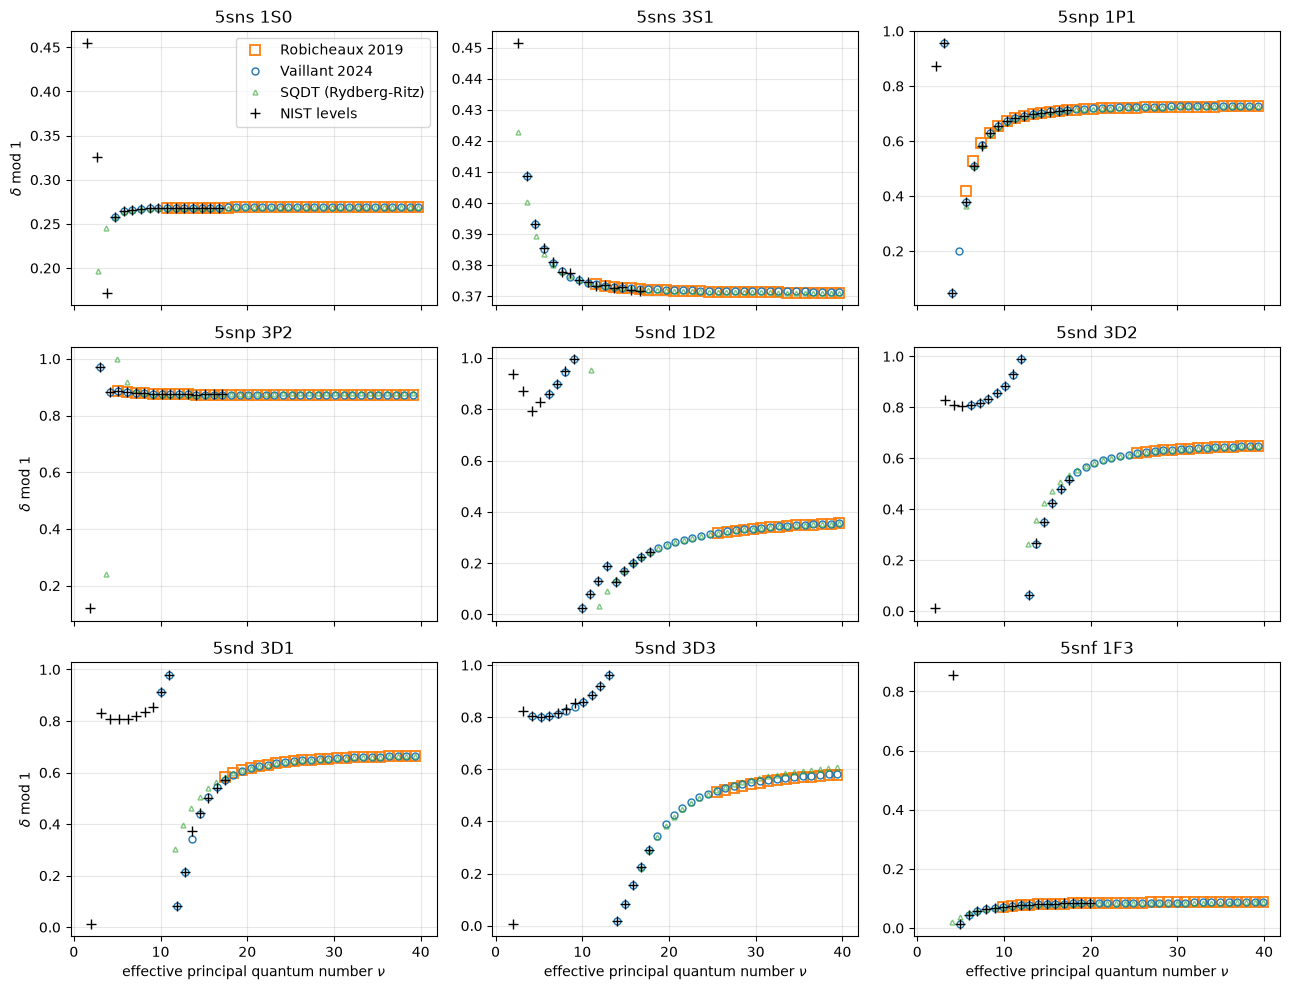

In [5]:
threshold_au = get_mqdt("Sr88", "robicheaux2019").reference_ionization_threshold_au  # Robicheaux and SQDT, see above
reduced_mass_au = sqdt.element_properties.reduced_mass_au


def nist_nus(l_r: int, j_tot: float, s_tot: float) -> np.ndarray:
    energies_au = [
        energy_au
        for (_n, l, j, s), energy_au in sqdt._nist_energy_levels.items()  # noqa: SLF001
        if (l, j, s) == (l_r, j_tot, s_tot)
    ]
    return np.array([calc_nu_from_energy(reduced_mass_au, e - threshold_au) for e in energies_au])


def fractional_quantum_defect(nus: np.ndarray) -> np.ndarray:
    return (-np.asarray(nus)) % 1


fig, axes = plt.subplots(3, 3, figsize=(13, 10), sharex=True)
for ax, (label, (l_r, f_tot, _parity, s_tot)) in zip(axes.flat, series.items(), strict=True):
    for key, basis in series_bases.items():
        nus = basis[label].calc_exp_qn("nu")
        ax.plot(nus, fractional_quantum_defect(nus), ls="none", mfc="none", label=key, **styles[key])
    nus = sqdt_series[label]
    ax.plot(nus, fractional_quantum_defect(nus), ls="none", mfc="none", label=SQDT_KEY, **styles[SQDT_KEY])
    nus = nist_nus(l_r, f_tot, spin(s_tot))
    ax.plot(nus, fractional_quantum_defect(nus), "k+", ms=7, label="NIST levels")
    ax.set_title(label)
    ax.grid(alpha=0.3)
for ax in axes[-1]:
    ax.set_xlabel(r"effective principal quantum number $\nu$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\delta \; \mathrm{mod} \; 1$")
axes[0, 0].legend()
fig.tight_layout()
plt.show()

The Vaillant models follow the NIST levels down to the lowest states of each series and reproduce the perturber
signatures in the D series (the quantum defect of the $5snd$ triplet series changes by almost one around
$\nu \approx 12$ to $18$ because of the $4d6s$ perturber). In the common range of validity both model sets agree closely,
with visible differences in the asymptotic quantum defects of the $5snp$ $^3P_2$ and $5snd$ $^3D_3$ series,
which the Vaillant models only fit up to $n = 15$ and $n = 29$, respectively.

The SQDT quantum defects agree with the MQDT models at high $\nu$ for most series, with a visible offset of the
asymptotic quantum defect in the $5snd$ $^3D_3$ series. Being single channel fits, they cannot reproduce the
perturbations: in the $5snd$ series they approach the perturbed region smoothly instead of following the steep rise of
the quantum defect (and their range of validity ends before the region where it changes by almost one).

## Energy differences

For every state of the Vaillant models we take the closest state (in energy) of the same series of the other model sets
and plot the energy difference. For the Robicheaux models we only consider the Vaillant states above the lowest
state of the corresponding Robicheaux model, i.e. the common range of validity.
Since the ionization thresholds of the model sets agree to 1 MHz, these differences reflect the different quantum defects
(a threshold difference $\Delta I$ shifts all energies of a model set rigidly by $\Delta I$, without changing $\nu$).
For the $5sns$ $^1S_0$ series, the two MQDT models agree to better than 35 MHz for $\nu > 20$
(below 10 MHz at $\nu \approx 40$).

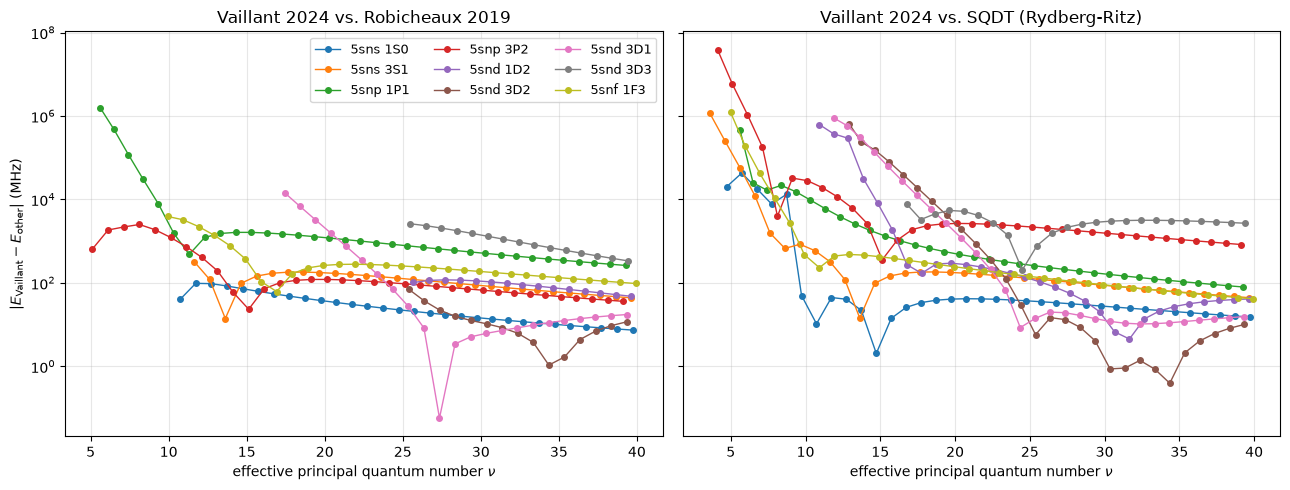

In [6]:
def energies_from_nus(nus: np.ndarray) -> np.ndarray:
    energies_au = np.array([threshold_au + calc_energy_from_nu(reduced_mass_au, nu) for nu in nus])
    return au_to_user(energies_au, "energy", "MHz")


def closest_energy_differences(reference: BasisMQDT, other_energies: np.ndarray, nu_min: float) -> tuple[list, list]:
    nus, diffs = [], []
    for state in reference.states:
        if state.nu < nu_min:
            continue
        energy = state.get_energy("MHz")
        nus.append(state.nu)
        diffs.append(np.min(np.abs(other_energies - energy)))
    return nus, diffs


fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for i, label in enumerate(series):
    new = series_bases["Vaillant 2024"][label]
    old = series_bases["Robicheaux 2019"][label]
    if len(old) > 0:
        old_energies = np.array([state.get_energy("MHz") for state in old.states])
        nus, diffs = closest_energy_differences(new, old_energies, old.states[0].nu - 0.4)
        axes[0].plot(nus, diffs, marker="o", ms=4, lw=1, color=f"C{i}", label=label)
    sqdt_energies = energies_from_nus(sqdt_series[label])
    nus, diffs = closest_energy_differences(new, sqdt_energies, sqdt_series[label][0] - 0.4)
    axes[1].plot(nus, diffs, marker="o", ms=4, lw=1, color=f"C{i}", label=label)
for ax, key in zip(axes, ["Robicheaux 2019", SQDT_KEY], strict=True):
    ax.set_yscale("log")
    ax.set_xlabel(r"effective principal quantum number $\nu$")
    ax.set_title(f"Vaillant 2024 vs. {key}")
    ax.grid(alpha=0.3)
axes[0].set_ylabel(r"$|E_\mathrm{Vaillant} - E_\mathrm{other}|$ (MHz)")
axes[0].legend(ncol=3, fontsize=9)
fig.tight_layout()
plt.show()

The SQDT energies agree with the Vaillant models to a few 10 MHz at $\nu \approx 40$ for the singlet series and the
$5sns$ $^3S_1$, $5snd$ $^3D_1$ and $^3D_2$ series, but deviate by about 0.8 GHz ($5snp$ $^3P_2$) and 2.7 GHz
($5snd$ $^3D_3$). For these two series the two MQDT model sets agree much better with each other
(within about 0.3 GHz) than with the SQDT model.
Towards lower $\nu$ the deviations grow quickly and reach the THz range in the perturbed $5snd$ series.

## Singlet-triplet mixing of the $5snd$ $J=2$ states

The $5snd$ $^1D_2$ and $^3D_2$ series are strongly mixed. The six channel Vaillant model describes the
mixing including its resonant enhancement around the $4d^2$ $^3P_2$ perturber ($\nu \approx 9.5$, i.e. in the
$5s15d$ states), whereas the Robicheaux model uses a constant mixing angle and is only valid for $\nu > 25$.
The SQDT states are pure singlet or triplet states, i.e. SQDT neglects the mixing completely.
The triplet fraction is the expectation value of the total spin $\langle S \rangle$ of the state.

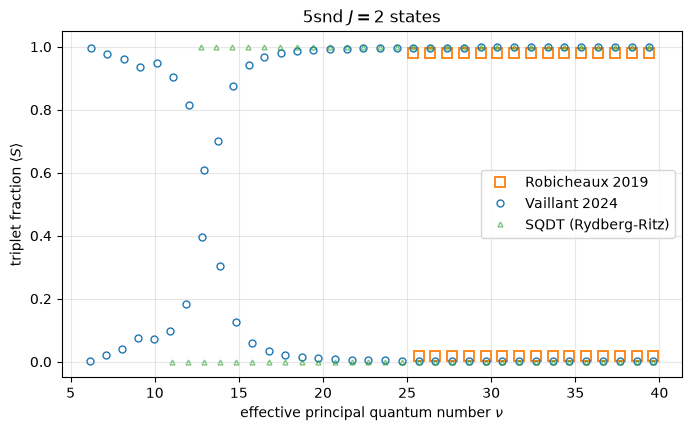

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for key, basis in bases.items():
    d2 = (
        basis.shallow_copy()
        .filter_states("f_tot", 2)
        .filter_states("parity", +1)
        .filter_states("l_c", (0, 0.5))
        .filter_states("l_r", (1.5, 2.5))
        .sort_states("nu")
    )
    ax.plot(d2.calc_exp_qn("nu"), d2.calc_exp_qn("s_tot"), ls="none", mfc="none", label=key, **styles[key])
nus_singlet, nus_triplet = sqdt_series["5snd 1D2"], sqdt_series["5snd 3D2"]  # pure singlet and triplet states
nus = np.concatenate([nus_singlet, nus_triplet])
s_tots = np.concatenate([np.zeros_like(nus_singlet), np.ones_like(nus_triplet)])
ax.plot(nus, s_tots, ls="none", mfc="none", label=SQDT_KEY, **styles[SQDT_KEY])
ax.set_xlabel(r"effective principal quantum number $\nu$")
ax.set_ylabel(r"triplet fraction $\langle S \rangle$")
ax.set_title(r"5snd $J=2$ states")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

## Perturber states

The Vaillant models contain the doubly excited perturber channels explicitly, so they also yield the perturber states
themselves, i.e. the states dominated by a channel with an excited core ($\langle l_c \rangle > 1/2$).
The Robicheaux models do not contain such states.

In [8]:
perturbers = bases["Vaillant 2024"].shallow_copy().filter_states("l_c", (0.5, 3)).sort_states("nu")

print(f"{'energy (1/cm)':>14s} {'nu':>7s} {'F':>3s} {'parity':>6s} {'<l_c>':>6s} {'<S>':>5s}  model")
for state in perturbers.states:
    print(
        f"{state.get_energy('1/cm'):14.3f} {state.nu:7.3f} {state.f_tot:3.0f} {state.parity:6d} "
        f"{state.calc_exp_qn('l_c'):6.2f} {state.calc_exp_qn('s_tot'):5.2f}  {state.model.name}"
    )

 energy (1/cm)      nu   F parity  <l_c>   <S>  model
     37292.073   3.564   0     -1   1.73  1.00  P J=0, nu > 2.8
     37302.730   3.566   1     -1   1.72  1.00  P J=1 triplet, nu > 2.8
     37336.590   3.573   2     -1   1.74  1.00  P J=2, nu > 2.8
     38007.742   3.721   3     -1   0.87  0.00  F J=3 singlet, nu > 3.5
     38444.013   3.828   0      1   0.74  0.15  S J=0, nu > 3.7
     39539.013   4.143   3     -1   0.75  0.00  F J=3 singlet, nu > 3.5
     44525.838   8.833   0      1   1.97  0.59  S J=0, nu > 3.7
     44730.547   9.556   2      1   1.89  0.97  D J=2, nu > 5.7


These are the $4d5p$ $^3P_{0,1,2}$ states at $\nu \approx 3.57$, the $4d5p$ $^1F_3$ state at $\nu \approx 3.72$,
the $4d^2$ $^3P_0$ state at $\nu \approx 8.83$ and the $4d^2$ $^3P_2$ state at $\nu \approx 9.56$
(the $5s7s$ $^1S_0$ state at $\nu \approx 3.83$ also appears here, since the model gives it a predominant $4dnd$ character).
Note that the radial wavefunctions of the closed perturber channels have channel quantum numbers $\nu_i \lesssim l_r + 1$,
for which rydstate warns about the inner boundary of the Numerov integration; the energies are not affected,
but matrix elements involving these components should be treated with care.

## Composition of a single state

Finally we look at the channel composition of one state in both model sets, the $5s30d$ $^1D_2$ state at
$\nu \approx 27.67$. The bars show the squared coefficients of the state on the FJ coupled channels.

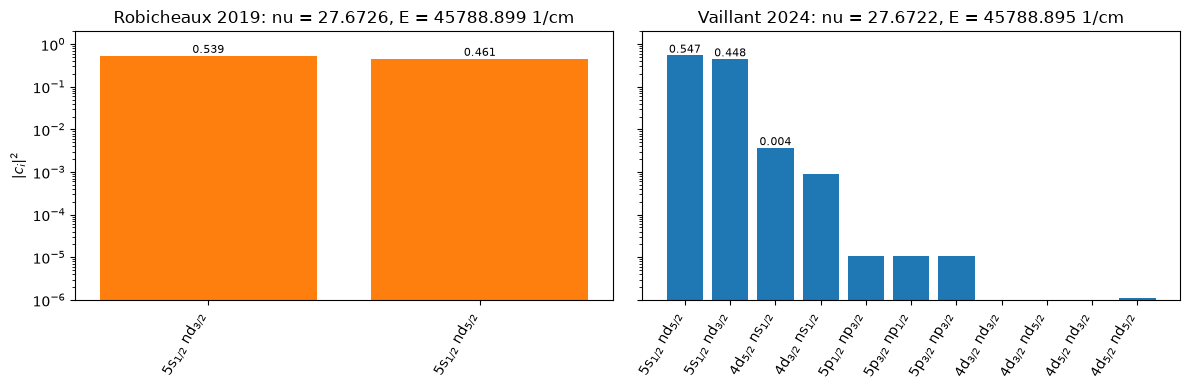

In [9]:
def ket_label(ket: RydbergKet) -> str:
    a = ket.angular
    return f"{a.n_c}{'spdf'[a.l_c]}$_{{{int(2 * a.j_c)}/2}}$ n{'spdf'[a.l_r]}$_{{{int(2 * a.j_r)}/2}}$"


fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, key in zip(axes, bases, strict=True):
    d2 = series_bases[key]["5snd 1D2"]
    state = min(d2.states, key=lambda s: abs(s.nu - 27.67))
    weights = np.abs(state.coefficients) ** 2
    labels = [ket_label(ket) for ket in state.rydberg_kets]
    ax.bar(range(len(weights)), weights, color=styles[key]["color"])
    ax.set_xticks(range(len(weights)), labels, rotation=60, ha="right")
    ax.set_title(f"{key}: nu = {state.nu:.4f}, E = {state.get_energy('1/cm'):.3f} 1/cm")
    for x, w in enumerate(weights):
        if w > 1e-3:
            ax.text(x, w, f"{w:.3f}", ha="center", va="bottom", fontsize=8)
axes[0].set_ylabel(r"$|c_i|^2$")
axes[0].set_yscale("log")
axes[0].set_ylim(1e-6, 2)
fig.tight_layout()
plt.show()

Both models describe the state as a superposition of the two $5s_{1/2}nd_j$ channels with a small admixture of the
other channel, but they differ in the size of the singlet-triplet mixing (0.3% vs 1.9% triplet admixture at $n = 30$,
see the previous plot), which is why the weights of the two $5s_{1/2}nd_j$ channels differ noticeably (a pure $^1D_2$
state would have weights 3/5 and 2/5). The Vaillant model additionally resolves the small $4dns$, $5pnp$ and $4dnd$
perturber admixtures.